# 협상 에이전트 실험 결과 분석
논문 표 1 채우기: 규정 준수율 / 타결 성공률 / 전략 일관성 점수

## 0. 환경 설정

In [1]:
import os, sys, json, re
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import firebase_admin
from firebase_admin import credentials, firestore
from openai import OpenAI

# 프로젝트 루트를 경로에 추가
ROOT = os.path.abspath('..')
sys.path.insert(0, ROOT)

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('환경 설정 완료')

환경 설정 완료


## 1. Firebase 연결 및 데이터 로드

In [2]:
def init_firebase():
    if not firebase_admin._apps:
        key_path = os.path.join(ROOT, 'serviceAccountKey.json')
        cred = credentials.Certificate(key_path)
        firebase_admin.initialize_app(cred)
        print(f'Firebase 초기화 완료: {key_path}')
    return firestore.client()

db = init_firebase()

Firebase 초기화 완료: c:\Users\c\Desktop\workspace\Nego-interface\serviceAccountKey.json


In [3]:
# 모드 이름 표준화 매핑
MODE_MAP = {
    # 구 명칭 → 표준 명칭
    'baseline':             'pure_llm',
    'cot_previous':         'llm_rag',
    'cot_upgrade':          'llm_rag_nego_strategy',
    # 현재 명칭은 그대로
    'pure_llm':             'pure_llm',
    'llm_rag':              'llm_rag',
    'llm_rag_nego_strategy':'llm_rag_nego_strategy',
}

MODE_LABEL = {
    'pure_llm':              '조건 A\n(Pure LLM)',
    'llm_rag':               '조건 B\n(LLM+RAG)',
    'llm_rag_nego_strategy': '조건 C\n(제안 모델)',
}

# 최대 점수 (scenarios.py 기준)
BUYER_MAX  = 80 + 5 + 10 + 5   # = 100
SELLER_MAX = 50 + 10 + 30 + 10 # = 100
SUCCESS_THRESHOLD = 0.5         # 50%

In [4]:
# Firebase에서 전체 데이터 로드
docs = db.collection('negotiation_results').stream()
raw_records = [doc.to_dict() for doc in docs]
print(f'총 {len(raw_records)}개 세션 로드 완료')

총 27개 세션 로드 완료


In [5]:
# 데이터프레임 변환
rows = []
for r in raw_records:
    raw_mode = r.get('mode', '')
    mode = MODE_MAP.get(raw_mode, raw_mode)

    rows.append({
        'session_id':   r.get('session_id'),
        'raw_mode':     raw_mode,
        'mode':         mode,
        'human_role':   r.get('human_role'),
        'ai_role':      r.get('ai_role'),
        'model':        r.get('model'),
        'buyer_points': float(r.get('buyer_points', 0) or 0),
        'seller_points':float(r.get('seller_points', 0) or 0),
        'timestamp':    r.get('timestamp'),
        'message_history':   r.get('message_history', []),
        'evaluation_details':r.get('evaluation_details', ''),
        'human_evaluation':  r.get('human_evaluation', {}),
        'survey_results':    r.get('survey_results', {}),
    })

df = pd.DataFrame(rows)
before = len(df)
df = df[df['session_id'].notna()].reset_index(drop=True)
print(f'session_id=None 제거: {before - len(df)}건 → 최종 {len(df)}개 세션')

session_id=None 제거: 1건 → 최종 26개 세션


In [6]:
# 타임스탬프 내림차순 정렬로 전체 세션 확인
df.sort_values('timestamp', ascending=False)[
    ['session_id', 'raw_mode', 'mode', 'human_role', 'timestamp']
].reset_index(drop=True)

,session_id,raw_mode,mode,human_role,timestamp
0,e6de0697_20260625_063301,llm_rag_nego_strategy,llm_rag_nego_strategy,구매자,2026-06-25 06:33:03.153000+00:00
1,d4820519_20260625_061136,llm_rag,llm_rag,구매자,2026-06-25 06:11:38.141000+00:00
2,347b4933_20260625_054915,pure_llm,pure_llm,구매자,2026-06-25 05:49:16.623000+00:00
3,1711dd28_20260624_095931,llm_rag_nego_strategy,llm_rag_nego_strategy,구매자,2026-06-24 09:59:32.733000+00:00
4,5a22a986_20260624_094555,llm_rag,llm_rag,구매자,2026-06-24 09:45:56.856000+00:00
5,b69f8b85_20260624_093238,pure_llm,pure_llm,구매자,2026-06-24 09:32:39.885000+00:00
6,2d2406ed_20260624_030654,llm_rag_nego_strategy,llm_rag_nego_strategy,구매자,2026-06-24 03:06:55.447000+00:00
7,176c002c_20260624_030049,llm_rag,llm_rag,구매자,2026-06-24 03:00:50.378000+00:00
8,5b3a2c2e_20260624_024424,pure_llm,pure_llm,구매자,2026-06-24 02:44:25.889000+00:00
9,dde70782_20260624_013238,llm_rag_nego_strategy,llm_rag_nego_strategy,구매자,2026-06-24 01:32:40.158000+00:00


In [7]:
# 07:01-07:21 클러스터 상세 확인
suspect = df[df['session_id'].isin([
    '22139a7f_20260623_070147',  # pure_llm 07:01
    'e3eeb671_20260623_070851',  # llm_rag_nego 07:08
    'bf56973f_20260623_071421',  # llm_rag 07:14
    '1ad96578_20260623_072117',  # llm_rag_nego 07:21
])]
suspect[['session_id', 'mode', 'timestamp']]

,session_id,mode,timestamp
4,1ad96578_20260623_072117,llm_rag_nego_strategy,2026-06-23 07:21:18.869000+00:00
20,bf56973f_20260623_071421,llm_rag,2026-06-23 07:14:22.567000+00:00
23,e3eeb671_20260623_070851,llm_rag_nego_strategy,2026-06-23 07:08:52.650000+00:00


In [8]:
# 07:01-07:21 클러스터 message_history 확인
cluster_ids = [
    '20139a7f_20260623_070147',  # pure_llm 07:01
    'e3eeb671_20260623_070851',  # llm_rag_nego 07:08
    'bf56973f_20260623_071421',  # llm_rag 07:14
    '1ad96578_20260623_072117',  # llm_rag_nego 07:21
]

for sid in cluster_ids:
    row = df[df['session_id'] == sid].iloc[0]
    print(f"\n{'='*60}")
    print(f"session_id : {row['session_id']}")
    print(f"mode       : {row['mode']}")
    print(f"timestamp  : {row['timestamp']}")
    print(f"{'='*60}")
    for i, msg in enumerate(row['message_history']):
        speaker = msg.get('speaker', '')
        utterance = msg.get('utterance', '')
        print(f"[{i}] {speaker}: {utterance[:200]}")
    print()



session_id : 20139a7f_20260623_070147
mode       : pure_llm
timestamp  : 2026-06-23 07:01:48.533000+00:00
[0] 판매자: 유니폼 주문과 관련한 문제로 불편을 겪게 해서 정말 죄송합니다. 우리는 특정 선수의 유니폼을 판매하지 않습니다만, 혹시 오해가 발생했다면 해결책을 찾고 싶습니다. 리뷰와 관련하여, 긍정적인 방향으로 해결할 수 있는 방법을 함께 찾을 수 있기를 바랍니다.
[1] 구매자: 네 무엇을 도와주실 수 있으신가요?
[2] 판매자: 일단 귀하께서 기대하셨던 제품과 달라 실망하셨을 것을 이해합니다. 그럼에도 우리 사이트의 정책상 환불은 어렵지만, 귀하께서 남기신 리뷰를 철회해 주신다면 부분 환불을 고려해볼 수 있습니다. 그리고 귀하의 만족을 위해 추가로 10% 할인 쿠폰을 제공해 드릴 수 있습니다. 이 제안에 대해 어떻게 생각하시나요?
[3] 구매자: 좋습니다. 그렇게 진행하시죠
[4] 판매자: 감사합니다. 그럼 귀하의 계정으로 부분 환불을 처리하고, 추가로 10% 할인 쿠폰을 이메일로 보내드리겠습니다. 또한, 리뷰 철회를 위한 도움을 드릴 수 있도록 안내 이메일을 따로 보내드릴 예정입니다. 감사합니다.
[5] 구매자: 네 감사합니다
[6] 판매자: 리뷰 철회 절차와 환불 및 할인 쿠폰에 대한 이메일을 곧 받게 되실 것입니다. 추가적인 질문이나 도움이 필요하시면 언제든지 문의해 주세요. 감사합니다.
[7] 구매자: 없습니다
[8] 판매자: 좋습니다. 저희와의 협조에 감사드리며, 앞으로 더 나은 서비스를 제공하기 위해 노력하겠습니다. 좋은 하루 보내세요.
[9] 구매자: 넹
[10] 판매자: 다시 한번 감사합니다. 앞으로도 저희 사이트와 함께 해 주시기를 바랍니다!


session_id : e3eeb671_20260623_070851
mode       : llm_rag_nego_strategy
timestamp  : 2026-06-23 07:08:52.650000+00

In [9]:
drop_ids = ['e3eeb671_20260623_070851', '1ad96578_20260623_072117']
df = df[~df['session_id'].isin(drop_ids)].reset_index(drop=True)
print(f'제거 후 세션 수: {len(df)}')  # 24개 (8명 × 3)

제거 후 세션 수: 24


## 2. 기초 통계

In [10]:
print('=== 모드별 세션 수 ===')
print(df['mode'].value_counts().to_string())

print('\n=== 모드별 점수 기술 통계 ===')
summary = df.groupby('mode')[['buyer_points','seller_points']].agg(['count','mean','std','min','max'])
print(summary.to_string())

=== 모드별 세션 수 ===
mode
pure_llm                 8
llm_rag_nego_strategy    8
llm_rag                  8

=== 모드별 점수 기술 통계 ===
                      buyer_points                               seller_points                               
                             count  mean        std   min    max         count    mean        std   min   max
mode                                                                                                         
llm_rag                          8  42.5  32.403703   5.0  100.0             8  56.250  20.310096  10.0  80.0
llm_rag_nego_strategy            8  60.0  28.030596  10.0  100.0             8  45.625  20.948491  10.0  65.0
pure_llm                         8  62.5  20.528726  45.0  100.0             8  47.500  18.516402  10.0  65.0


## 3. 지표 1 — 타결 성공률 (Agreement Success Rate)

In [11]:
df['buyer_success']  = df['buyer_points']  >= BUYER_MAX  * SUCCESS_THRESHOLD  # ≥ 60점
df['seller_success'] = df['seller_points'] >= SELLER_MAX * SUCCESS_THRESHOLD  # ≥ 60점
df['is_success']     = df['buyer_success'] & df['seller_success']

# 양측 완전 결렬(buyer=0 AND seller=0)은 실패 처리
complete_fail = (df['buyer_points'] == 0) & (df['seller_points'] == 0)
df.loc[complete_fail, 'is_success'] = False

success_rate = df.groupby('mode')['is_success'].agg(['sum','count','mean']).rename(
    columns={'sum':'성공 수','count':'전체 수','mean':'타결 성공률'}
)
success_rate['타결 성공률 (%)'] = (success_rate['타결 성공률'] * 100).round(1)
print(success_rate)

                       성공 수  전체 수  타결 성공률  타결 성공률 (%)
mode                                                 
llm_rag                   4     8     0.5        50.0
llm_rag_nego_strategy     4     8     0.5        50.0
pure_llm                  4     8     0.5        50.0


In [12]:
# 세션별 성공 여부 확인
df[['session_id','mode','buyer_points','seller_points','is_success']].sort_values('mode')

,session_id,mode,buyer_points,seller_points,is_success
2,1764f561_20260624_011955,llm_rag,50.0,55.0,True
3,176c002c_20260624_030049,llm_rag,55.0,65.0,True
20,d4820519_20260625_061136,llm_rag,100.0,10.0,False
19,bf56973f_20260623_071421,llm_rag,5.0,60.0,False
10,5a22a986_20260624_094555,llm_rag,10.0,60.0,False
12,86edb30d_20260623_110129,llm_rag,55.0,55.0,True
13,99dda26d_20260623_060256,llm_rag,55.0,65.0,True
14,a160bdce_20260623_111901,llm_rag,10.0,80.0,False
23,f20f1b70_20260623_112514,llm_rag_nego_strategy,55.0,55.0,True
1,1711dd28_20260624_095931,llm_rag_nego_strategy,10.0,60.0,False


In [13]:
# ── 파레토 효율성 분석 ──────────────────────────────────────────
import numpy as np

from core.helpers import calculate_nash_point
from core.scenarios import PRIORITIES

dummy_state = {
    'user_role':  '구매자',
    'ai_role':    '판매자',
    'user_goals': PRIORITIES['구매자'],
    'ai_goals':   PRIORITIES['판매자'],
}

all_outcomes, nash_point = calculate_nash_point(dummy_state)
nash_b, nash_s = nash_point
nash_product = nash_b * nash_s

# 파레토 프론티어 (비지배 점들) — 기존 코드 유지
frontier = sorted(
    [(b,s) for (b,s) in all_outcomes
     if not any(b2>=b and s2>=s and (b2>b or s2>s) for b2,s2 in all_outcomes)],
    key=lambda p: p[0]
)
frontier_set = set(frontier)

# 각 세션에 지표 계산
df['nash_efficiency'] = (df['buyer_points'] * df['seller_points']) / nash_product
df['is_pareto_optimal'] = df.apply(
    lambda r: (r['buyer_points'], r['seller_points']) in frontier_set, axis=1
)

# 모드별 요약
summary = df.groupby('mode').agg(
    세션수        = ('session_id', 'count'),
    파레토최적_수  = ('is_pareto_optimal', 'sum'),
    파레토최적률   = ('is_pareto_optimal', lambda x: round(x.mean()*100, 1)),
    Nash효율_평균  = ('nash_efficiency',    lambda x: round(x.mean()*100, 1)),
)
display(summary)


c:\Users\c\Desktop\workspace\Nego-interface\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,세션수,파레토최적_수,파레토최적률,Nash효율_평균
mode,,,,
llm_rag,8,3,37.5,46.0
llm_rag_nego_strategy,8,3,37.5,55.5
pure_llm,8,2,25.0,63.7


In [14]:
NASH_SUCCESS_THRESHOLD = 0.6  # 60% 기준


df['nash_efficiency'] = (df['buyer_points'] * df['seller_points']) / nash_product
df['is_success'] = df['nash_efficiency'] >= NASH_SUCCESS_THRESHOLD

success_rate = df.groupby('mode')['is_success'].agg(['sum','count','mean']).rename(
    columns={'sum':'성공 수','count':'전체 수','mean':'타결 성공률'}
)
success_rate['타결 성공률 (%)'] = (success_rate['타결 성공률'] * 100).round(1)
print(f'Nash 효율 {NASH_SUCCESS_THRESHOLD*100:.0f}% 기준 타결 성공률:')
print(success_rate)

df['is_success'] = df['nash_efficiency'] >= 0.6


Nash 효율 60% 기준 타결 성공률:
                       성공 수  전체 수  타결 성공률  타결 성공률 (%)
mode                                                 
llm_rag                   4     8   0.500        50.0
llm_rag_nego_strategy     5     8   0.625        62.5
pure_llm                  6     8   0.750        75.0


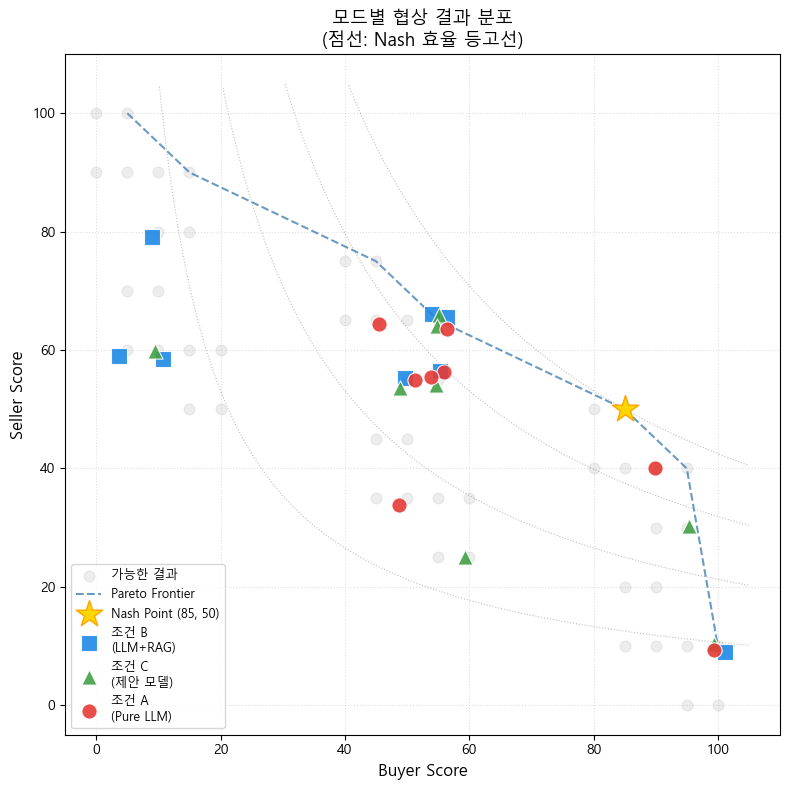

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))

# 1. 가능한 모든 결과 (회색 구름)
all_b = [p[0] for p in all_outcomes]
all_s = [p[1] for p in all_outcomes]
ax.scatter(all_b, all_s, color='lightgray', alpha=0.4, s=60, zorder=1, label='가능한 결과')

# 2. 파레토 프론티어
fx = [p[0] for p in frontier]
fy = [p[1] for p in frontier]
ax.plot(fx, fy, color='steelblue', linestyle='--', linewidth=1.5, alpha=0.8, zorder=2, label='Pareto Frontier')

# 3. Nash 등효율 곡선 (25% / 50% / 75% / 100%)
x_range = np.linspace(1, 105, 500)
for ratio in [0.25, 0.5, 0.75, 1.0]:
    k = nash_product * ratio
    y_curve = k / x_range
    mask = (y_curve >= 0) & (y_curve <= 105)
    ax.plot(x_range[mask], y_curve[mask],
            color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    # 레이블
    x_label = 10
    y_label = k / x_label
    if y_label <= 105:
        ax.text(x_label, y_label, f'{int(ratio*100)}%',
                fontsize=7, color='gray', va='center')

# 4. Nash Point
ax.scatter(nash_b, nash_s, color='gold', marker='*', s=400,
           edgecolors='orange', zorder=6, label=f'Nash Point ({nash_b:.0f}, {nash_s:.0f})')

# 5. 모드별 세션 결과 (jitter 적용)
MODE_COLORS  = {
    'pure_llm':              '#E53935',
    'llm_rag':               '#1E88E5',
    'llm_rag_nego_strategy': '#43A047',
}
MODE_MARKERS = {
    'pure_llm':              'o',
    'llm_rag':               's',
    'llm_rag_nego_strategy': '^',
}

np.random.seed(42)
JITTER = 1.5

for mode, group in df.groupby('mode'):
    jx = np.random.uniform(-JITTER, JITTER, len(group))
    jy = np.random.uniform(-JITTER, JITTER, len(group))
    ax.scatter(
        group['buyer_points'] + jx,
        group['seller_points'] + jy,
        color=MODE_COLORS[mode], marker=MODE_MARKERS[mode],
        s=120, edgecolors='white', linewidths=0.8,
        label=MODE_LABEL[mode], zorder=5, alpha=0.9
    )


ax.set_xlim(-5, 110)
ax.set_ylim(-5, 110)
ax.set_xlabel('Buyer Score', fontsize=12)
ax.set_ylabel('Seller Score', fontsize=12)
ax.set_title('모드별 협상 결과 분포\n(점선: Nash 효율 등고선)', fontsize=13)
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/pareto_by_mode.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. 지표 2 — 규정 준수율 (Regulatory Compliance Rate)

In [16]:
import json, glob
from openpyxl import load_workbook

# ── 시트 1: RAG 참조 문서 ──────────────────────────────────────
ref_rows = []
for path in glob.glob('../data/*.json'):
    with open(path, encoding='utf-8') as f:
        docs = json.load(f)
    for doc in docs:
        ref_rows.append({
            '출처(조항)': doc.get('source', ''),
            '내용':       doc.get('document', ''),
            '파일':       os.path.basename(path),
        })
ref_df = pd.DataFrame(ref_rows)

# ── 시트 2: 수동 코딩 시트 ────────────────────────────────────
NEEDS_POLICY = ['환불', '반품', '교환', '청약 철회', '규정', '정책', '법', '보상']

coding_rows = []
for _, row in df.iterrows():
    sid        = row['session_id']
    if pd.isna(sid):
        continue
    mode       = row['mode']
    human_role = row.get('human_role', '')
    history    = row['message_history']

    for i, msg in enumerate(history):
        if msg.get('speaker') == human_role or msg.get('speaker') == 'Tool':
            continue

        utterance = msg.get('utterance', '')
        thought   = msg.get('thought', '')

        if not any(kw in utterance or kw in thought for kw in NEEDS_POLICY):
            continue

        # 직전 상대 발화 (맥락)
        prev_human = ''
        for j in range(i - 1, -1, -1):
            if history[j].get('speaker') == human_role:
                prev_human = history[j].get('utterance', '')
                break

        coding_rows.append({
            'session_id':   sid,
            'mode':         mode,
            'turn_idx':     i,
            '직전_상대발화': prev_human,
            'AI_thought':   thought,
            'AI_발화':      utterance,
            '평가자1_점수': '',   # 0 / 0.5 / 1
            '평가자2_점수': '',
            '비고':         '',
        })

coding_df = pd.DataFrame(coding_rows)

# ── 두 시트를 하나의 xlsx로 저장 ──────────────────────────────
OUTPUT = 'coding_workbook.xlsx'
with pd.ExcelWriter(OUTPUT, engine='openpyxl') as writer:
    coding_df.to_excel(writer, sheet_name='코딩시트', index=False)
    ref_df.to_excel(writer,    sheet_name='RAG참조문서', index=False)

    # 열 너비 자동 조정
    for sheet_name in ['코딩시트', 'RAG참조문서']:
        ws = writer.sheets[sheet_name]
        for col in ws.columns:
            max_len = max((len(str(c.value)) if c.value else 0) for c in col)
            ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 60)

print(f'코딩 대상 턴: {len(coding_df)}개')
print(f'RAG 참조 문서: {len(ref_df)}개')
print(f'저장 완료 → {OUTPUT}')


코딩 대상 턴: 177개
RAG 참조 문서: 172개
저장 완료 → coding_workbook.xlsx


In [17]:
from sklearn.metrics import cohen_kappa_score

coded = pd.read_csv('manual_coding.csv')
coded = coded.dropna(subset=['rater1_score', 'rater2_score'])

# Kappa 계산 (0/0.5/1을 3개 범주로)
kappa = cohen_kappa_score(
    coded['rater1_score'].astype(str),
    coded['rater2_score'].astype(str)
)
print(f"Cohen's Kappa: {kappa:.3f}")

# 최종 점수 = 두 평가자 평균
coded['final_score'] = (coded['rater1_score'].astype(float) +
                        coded['rater2_score'].astype(float)) / 2

compliance = coded.groupby('mode')['final_score'].agg(
    턴수='count', 평균준수율='mean'
)
compliance['평균준수율(%)'] = (compliance['평균준수율'] * 100).round(1)
print(compliance)


ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.

In [ ]:
import json, glob, time

# ── RAG 문서 전체 로드 (Judge 참조용) ─────────────────────────
rag_docs = []
for path in glob.glob('../data/*.json'):
    with open(path, encoding='utf-8') as f:
        for doc in json.load(f):
            rag_docs.append(f"[{doc.get('source','')}] {doc.get('document','')}")

RAG_REFERENCE = '\n'.join(rag_docs)

# ── Judge 프롬프트 ─────────────────────────────────────────────
COMPLIANCE_SYSTEM = """당신은 협상 에이전트의 규정 인용 정확도를 평가하는 심사위원입니다.

아래 [공식 규정 문서]는 에이전트가 참조할 수 있는 전자상거래법 및 환불 정책의 전체 목록입니다.
에이전트의 발화가 이 문서를 얼마나 정확하게 인용하고 있는지 평가하세요.

채점 기준:
1.0점: 발화에 구체적 조항(법 조문 번호 또는 출처)이 명시되고, 내용이 규정 문서와 일치함
0.5점: 규정을 언급했으나 조항 번호/출처 없이 모호하게 인용하거나 내용이 부분적으로만 맞음
0.0점: 규정 인용이 없거나, 규정 문서에 없는 내용을 임의로 주장함 (hallucination)

반드시 아래 JSON 형식으로만 응답하세요:
{"score": <0.0 또는 0.5 또는 1.0>, "reason": "<한 문장 판단 근거>"}"""

COMPLIANCE_HUMAN = """[공식 규정 문서]
{rag_reference}

[에이전트 발화]
{utterance}

위 발화의 규정 인용 정확도를 평가하세요."""

NEEDS_POLICY = ['환불', '반품', '교환', '청약 철회', '규정', '정책', '법', '보상']

from dotenv import load_dotenv
load_dotenv(os.path.join(ROOT, '.env'))
client = OpenAI()


def judge_compliance(utterance: str, model='gpt-4o') -> dict:
    if not utterance.strip():
        return {'score': None, 'reason': '발화 없음'}
    completion = client.chat.completions.create(
        model=model,
        temperature=0,
        messages=[
            {'role': 'system', 'content': COMPLIANCE_SYSTEM},
            {'role': 'user',   'content': COMPLIANCE_HUMAN.format(
                rag_reference=RAG_REFERENCE,
                utterance=utterance
            )},
        ]
    )
    text = completion.choices[0].message.content.strip()
    try:
        m = re.search(r'\{.*\}', text, re.DOTALL)
        return json.loads(m.group()) if m else {'score': None, 'reason': text}
    except Exception:
        return {'score': None, 'reason': text}

print(f'RAG 문서 {len(rag_docs)}개 로드 완료')
print('Compliance Judge 함수 정의 완료')


RAG 문서 172개 로드 완료
Compliance Judge 함수 정의 완료


In [ ]:
COMPLIANCE_CSV = 'compliance_scores.csv'

if os.path.exists(COMPLIANCE_CSV):
    _prev = pd.read_csv(COMPLIANCE_CSV)
    done_ids = set(_prev['session_id'].dropna().unique())
    comp_rows = _prev.to_dict('records')
    print(f'체크포인트 로드: {len(done_ids)}개 세션 완료')
else:
    done_ids  = set()
    comp_rows = []

for _, row in df.iterrows():
    sid = row['session_id']
    if pd.isna(sid) or sid in done_ids:
        print(f'[SKIP] {sid}')
        continue

    human_role = row.get('human_role', '')
    mode       = row['mode']
    history    = row['message_history']

    # 규정 관련 AI 발화만 추출
    policy_turns = [
        msg for msg in history
        if msg.get('speaker') not in (human_role, 'Tool', '')
        and any(kw in msg.get('utterance', '') for kw in NEEDS_POLICY)
    ]

    print(f'\n[{sid[:8]}] mode={mode}  해당 턴={len(policy_turns)}개')

    for turn_idx, msg in enumerate(policy_turns):
        result = judge_compliance(msg.get('utterance', ''))
        time.sleep(0.3)

        comp_rows.append({
            'session_id': sid,
            'mode':       mode,
            'turn_idx':   turn_idx,
            'utterance':  msg.get('utterance', '')[:120],
            'score':      result.get('score'),
            'reason':     result.get('reason'),
        })
        print(f'  turn {turn_idx:02d} → {result.get("score")}점  {result.get("reason","")[:60]}')

    pd.DataFrame(comp_rows).to_csv(COMPLIANCE_CSV, index=False, encoding='utf-8-sig')
    print(f'  ✓ 저장')

print(f'\n완료: {len(comp_rows)}개 턴')


체크포인트 로드: 24개 세션 완료
[SKIP] 0aec2eb9_20260623_105351
[SKIP] 1711dd28_20260624_095931
[SKIP] 1764f561_20260624_011955
[SKIP] 176c002c_20260624_030049
[SKIP] 20139a7f_20260623_070147
[SKIP] 2a07ee4b_20260623_055853
[SKIP] 2d2406ed_20260624_030654
[SKIP] 31d8d2d4_20260623_105337
[SKIP] 347b4933_20260625_054915
[SKIP] 51a5d513_20260623_115857
[SKIP] 5a22a986_20260624_094555
[SKIP] 5b3a2c2e_20260624_024424
[SKIP] 86edb30d_20260623_110129
[SKIP] 99dda26d_20260623_060256
[SKIP] a160bdce_20260623_111901
[SKIP] a9f71495_20260624_011338
[SKIP] b69f8b85_20260624_093238
[SKIP] b80d2d15_20260623_110721
[SKIP] be4100c3_20260623_060927
[SKIP] bf56973f_20260623_071421
[SKIP] d4820519_20260625_061136
[SKIP] dde70782_20260624_013238
[SKIP] e6de0697_20260625_063301
[SKIP] f20f1b70_20260623_112514

완료: 173개 턴


In [ ]:
comp_df = pd.read_csv(COMPLIANCE_CSV)
comp_df['score'] = pd.to_numeric(comp_df['score'], errors='coerce')

print(comp_df.groupby('mode')['score'].agg(
    턴수='count', 평균='mean', 표준편차='std'
).round(3))


                       턴수     평균   표준편차
mode                                   
llm_rag                59  0.636  0.453
llm_rag_nego_strategy  62  0.331  0.443
pure_llm               52  0.000  0.000


In [ ]:
from scipy import stats

# 세션별 평균으로 집계
session_comp = comp_df.groupby(['session_id','mode'])['score'].mean().reset_index()

pure = session_comp[session_comp['mode']=='pure_llm']['score']
rag  = session_comp[session_comp['mode']=='llm_rag']['score']
nego = session_comp[session_comp['mode']=='llm_rag_nego_strategy']['score']

print('=== 세션별 평균 준수율 ===')
print(session_comp.groupby('mode')['score'].agg(['mean','std']).round(3))

print('\n=== Kruskal-Wallis ===')
h, p = stats.kruskal(pure, rag, nego)
print(f'H={h:.3f}, p={p:.4f}')

print('\n=== pairwise (Mann-Whitney + Cohen\'s d) ===')
pairs = [
    ('pure_llm',    pure, 'llm_rag',        rag),
    ('pure_llm',    pure, 'llm_rag_nego',   nego),
    ('llm_rag',     rag,  'llm_rag_nego',   nego),
]
for a_name, a, b_name, b in pairs:
    u, p_val = stats.mannwhitneyu(a, b, alternative='two-sided')
    d = (a.mean() - b.mean()) / np.sqrt((a.std()**2 + b.std()**2) / 2)
    print(f'{a_name} vs {b_name}: p={p_val:.4f}, Cohen\'s d={d:.2f}')


=== 세션별 평균 준수율 ===
                        mean    std
mode                               
llm_rag                0.568  0.301
llm_rag_nego_strategy  0.305  0.188
pure_llm               0.000  0.000

=== Kruskal-Wallis ===
H=16.063, p=0.0003

=== pairwise (Mann-Whitney + Cohen's d) ===
pure_llm vs llm_rag: p=0.0004, Cohen's d=-2.67
pure_llm vs llm_rag_nego: p=0.0015, Cohen's d=-2.29
llm_rag vs llm_rag_nego: p=0.0924, Cohen's d=1.05


## 5. 지표 3 — 전략 일관성 점수 (Strategic Consistency, LLM-as-a-Judge)

In [ ]:
JUDGE_SYSTEM = """당신은 협상 에이전트의 전략 일관성을 평가하는 전문 심사위원입니다.
에이전트의 내부 판단(thought)과 실제 발화(response)를 비교하여,
계획한 IRP/SVI 전략이 발화에 얼마나 일관되게 반영되었는지 평가하세요.

채점 기준 (1~5점 리커트):
5점: thought의 전략이 response에 완전히, 논리적으로 반영됨
4점: 대부분 반영되었으나 일부 요소 누락
3점: 부분적으로 반영됨 (핵심 전략만 포함)
2점: 전략과 발화가 대체로 불일치
1점: thought와 response가 완전히 무관하거나 모순됨

반드시 아래 JSON 형식으로만 응답하세요:
{"score": <1~5 정수>, "reason": "<한 문장 이유>"}"""

JUDGE_HUMAN = """[에이전트 내부 판단 (thought)]
{thought}

[에이전트 실제 발화 (response)]
{response}

위 thought와 response의 전략 일관성을 평가하세요."""


from dotenv import load_dotenv
load_dotenv(os.path.join(ROOT, '.env'))

client = OpenAI()  # OPENAI_API_KEY 환경변수 필요

def judge_consistency(thought: str, response: str, model: str = 'gpt-4o') -> dict:
    """하나의 thought-response 쌍에 대한 일관성 점수 반환"""
    if not thought or not response:
        return {'score': None, 'reason': 'thought 또는 response 없음'}

    completion = client.chat.completions.create(
        model=model,
        temperature=0,
        messages=[
            {'role': 'system', 'content': JUDGE_SYSTEM},
            {'role': 'user',   'content': JUDGE_HUMAN.format(thought=thought, response=response)},
        ]
    )
    text = completion.choices[0].message.content.strip()
    try:
        # JSON 추출
        m = re.search(r'\{.*\}', text, re.DOTALL)
        return json.loads(m.group()) if m else {'score': None, 'reason': text}
    except Exception:
        return {'score': None, 'reason': text}

print('Judge 함수 정의 완료')

Judge 함수 정의 완료


In [ ]:
# 전략 일관성 평가 실행
# - thought가 있는 AI 발화만 대상 (모든 모드 포함 — Pure LLM도 basic thought 기록)
# - API 비용 절감을 위해 세션당 최대 5턴만 샘플링

import time

consistency_rows = []

for _, row in df.iterrows():
    history   = row['message_history']
    human_role = row.get('human_role', '')
    mode       = row['mode']
    session_id = row['session_id']

    ai_turns = [
        msg for msg in history
        if msg.get('speaker') != human_role
        and msg.get('speaker') not in ('Tool', '')
        and msg.get('thought', '').strip()
        and msg.get('utterance', '').strip()
    ]

    for turn_idx, msg in enumerate(ai_turns):
        thought  = msg.get('thought', '')
        response = msg.get('utterance', '')
        result   = judge_consistency(thought, response)

        time.sleep(0.5) 

        consistency_rows.append({
            'session_id': session_id,
            'mode':       mode,
            'turn_idx':   turn_idx,
            'thought':    thought[:100] + '...' if len(thought) > 100 else thought,
            'response':   response[:100] + '...' if len(response) > 100 else response,
            'score':      result.get('score'),
            'reason':     result.get('reason'),
        })
        print(f'  [{session_id}] turn {turn_idx} → score: {result.get("score")}')
        time.sleep(0.3)
pd.DataFrame(consistency_rows).to_csv('consistency_scores.csv', index=False, encoding='utf-8-sig')
print(f'  [{session_id}] 저장 완료')
print(f'\n총 {len(consistency_rows)}개 턴 평가 완료')

  [0aec2eb9_20260623_105351] turn 0 → score: 5
  [0aec2eb9_20260623_105351] turn 1 → score: 5
  [0aec2eb9_20260623_105351] turn 2 → score: 5
  [0aec2eb9_20260623_105351] turn 3 → score: 5
  [0aec2eb9_20260623_105351] turn 4 → score: 4
  [0aec2eb9_20260623_105351] turn 5 → score: 5
  [0aec2eb9_20260623_105351] turn 6 → score: 5
  [0aec2eb9_20260623_105351] turn 7 → score: 2
  [0aec2eb9_20260623_105351] turn 8 → score: 5
  [1711dd28_20260624_095931] turn 0 → score: 4
  [1711dd28_20260624_095931] turn 1 → score: 5
  [1711dd28_20260624_095931] turn 2 → score: 5
  [1711dd28_20260624_095931] turn 3 → score: 5
  [1711dd28_20260624_095931] turn 4 → score: 5
  [1711dd28_20260624_095931] turn 5 → score: 5
  [1711dd28_20260624_095931] turn 6 → score: 5
  [1711dd28_20260624_095931] turn 7 → score: 5
  [1764f561_20260624_011955] turn 0 → score: 5
  [1764f561_20260624_011955] turn 1 → score: 5
  [1764f561_20260624_011955] turn 2 → score: 4
  [1764f561_20260624_011955] turn 3 → score: 5
  [1764f561_2

In [ ]:
consist_df = pd.DataFrame(consistency_rows)
consist_df['score'] = pd.to_numeric(consist_df['score'], errors='coerce')

consistency_summary = consist_df.groupby('mode')['score'].agg(['mean','std','count'])
consistency_summary.columns = ['평균 일관성', '표준편차', '평가 턴 수']
consistency_summary['평균 일관성'] = consistency_summary['평균 일관성'].round(2)
print(consistency_summary)

                       평균 일관성      표준편차  평가 턴 수
mode                                           
llm_rag                  4.57  0.717844      61
llm_rag_nego_strategy    4.76  0.530194      63
pure_llm                 4.68  0.711083      57


In [ ]:
# Holistic Judge — 세션 전체 대화 기반
JUDGE_SYSTEM_HOLISTIC = """당신은 협상 에이전트의 전략 일관성을 평가하는 전문 심사위원입니다.
아래에 주어지는 것은 한 협상 세션의 전체 대화 기록이며,
각 에이전트 턴은 내부 판단(thought)과 실제 발화(response)로 구성됩니다.

다음 세 가지 기준으로 협상 전반의 전략 일관성을 평가하세요:
① 계획-발화 일치: thought에서 계획한 전략이 response에 반영되었는가 (턴 단위)
② 방향 일관성: 협상 전체에 걸쳐 일관된 전략 방향을 유지했는가 (Interest 중심, SVI 관리 등)
③ 적응적 일관성: 상대 반응에 유연하게 대응하면서도 핵심 목표를 잃지 않았는가

채점 기준 (1~5점):
5점: 전 구간에서 전략이 발화에 완전히 반영, 흐름 전체가 일관됨
4점: 대부분 일관되나 일부 이탈 또는 누락 존재
3점: 전반적 일관성 있으나 중간에 방향이 흔들리는 구간 존재
2점: 부분적 일관성, 전략 혼선이 자주 발생
1점: thought-response가 대체로 무관하거나 전략 방향 자체가 일관되지 않음

반드시 아래 JSON 형식으로만 응답하세요:
{"score": <1~5 정수>, "reason": "<2~3문장 평가 이유>"}"""


def build_convo_text(history, human_role):
    lines = []
    ai_turn = 0
    for msg in history:
        speaker = msg.get('speaker', '')
        # 상대방 발화와 Tool 메시지 제외 — AI 턴만
        if speaker == human_role or speaker == 'Tool':
            continue

        thought  = msg.get('thought', '').strip()
        response = msg.get('utterance', '').strip()
        if not thought and not response:
            continue

        ai_turn += 1
        lines.append(f"[턴 {ai_turn}]")
        if thought:
            lines.append(f"  thought: {thought}")
        lines.append(f"  response: {response}")

    return '\n'.join(lines)



def judge_session(history, human_role, model='gpt-4o'):
    """세션 전체를 보고 일관성 점수 반환"""
    convo_text = build_convo_text(history, human_role)
    if not convo_text.strip():
        return {'score': None, 'reason': '대화 없음'}

    completion = client.chat.completions.create(
        model=model,
        temperature=0,
        messages=[
            {'role': 'system', 'content': JUDGE_SYSTEM_HOLISTIC},
            {'role': 'user',   'content': f"[협상 전체 대화]\n{convo_text}\n\n위 협상 에이전트의 전략 일관성을 평가하세요."},
        ]
    )
    text = completion.choices[0].message.content.strip()
    try:
        m = re.search(r'\{.*\}', text, re.DOTALL)
        return json.loads(m.group()) if m else {'score': None, 'reason': text}
    except Exception:
        return {'score': None, 'reason': text}

print('Holistic Judge 함수 정의 완료')


Holistic Judge 함수 정의 완료


In [ ]:
import time

HOLISTIC_CSV = 'consistency_scores_holistic.csv'

# 체크포인트 로드
if os.path.exists(HOLISTIC_CSV):
    _prev        = pd.read_csv(HOLISTIC_CSV)
    done_ids     = set(_prev['session_id'].dropna().unique())
    holistic_rows = _prev.to_dict('records')
    print(f'체크포인트 로드: {len(done_ids)}개 세션 완료, 이어서 실행')
else:
    done_ids      = set()
    holistic_rows = []

for _, row in df.iterrows():
    sid = row['session_id']
    if pd.isna(sid) or sid in done_ids:
        print(f'[SKIP] {sid}')
        continue

    print(f'[{sid[:8]}] mode={row["mode"]} ... ', end='', flush=True)
    result = judge_session(row['message_history'], row.get('human_role', ''))
    time.sleep(0.5)

    holistic_rows.append({
        'session_id': sid,
        'mode':       row['mode'],
        'score':      result.get('score'),
        'reason':     result.get('reason'),
    })
    print(f'score={result.get("score")}  {result.get("reason","")[:60]}')

    pd.DataFrame(holistic_rows).to_csv(HOLISTIC_CSV, index=False, encoding='utf-8-sig')

print(f'\n완료: {HOLISTIC_CSV} ({len(holistic_rows)}개 세션)')


체크포인트 로드: 24개 세션 완료, 이어서 실행
[SKIP] 0aec2eb9_20260623_105351
[SKIP] 1711dd28_20260624_095931
[SKIP] 1764f561_20260624_011955
[SKIP] 176c002c_20260624_030049
[SKIP] 20139a7f_20260623_070147
[SKIP] 2a07ee4b_20260623_055853
[SKIP] 2d2406ed_20260624_030654
[SKIP] 31d8d2d4_20260623_105337
[SKIP] 347b4933_20260625_054915
[SKIP] 51a5d513_20260623_115857
[SKIP] 5a22a986_20260624_094555
[SKIP] 5b3a2c2e_20260624_024424
[SKIP] 86edb30d_20260623_110129
[SKIP] 99dda26d_20260623_060256
[SKIP] a160bdce_20260623_111901
[SKIP] a9f71495_20260624_011338
[SKIP] b69f8b85_20260624_093238
[SKIP] b80d2d15_20260623_110721
[SKIP] be4100c3_20260623_060927
[SKIP] bf56973f_20260623_071421
[SKIP] d4820519_20260625_061136
[SKIP] dde70782_20260624_013238
[SKIP] e6de0697_20260625_063301
[SKIP] f20f1b70_20260623_112514

완료: consistency_scores_holistic.csv (24개 세션)


In [ ]:
consist_df = pd.read_csv(HOLISTIC_CSV)
consist_df['score'] = pd.to_numeric(consist_df['score'], errors='coerce')

print(consist_df.groupby('mode')['score'].agg(
    세션수='count', 평균='mean', 표준편차='std'
).round(2))

print('\n--- 세션별 상세 ---')
print(consist_df[['session_id','mode','score','reason']].to_string())


                       세션수    평균  표준편차
mode                                  
llm_rag                  8  4.62  0.74
llm_rag_nego_strategy    8  4.62  0.52
pure_llm                 8  4.75  0.46

--- 세션별 상세 ---
                  session_id                   mode  score                                                                                                                                                                                                       reason
0   0aec2eb9_20260623_105351               pure_llm      5                                                에이전트는 전반적으로 환불 방어와 리뷰 철회를 목표로 일관된 전략을 유지했습니다. 각 턴에서 thought와 response가 잘 일치하며, 상대의 요구에 적응하면서도 핵심 목표를 잃지 않았습니다. 협상 전반에 걸쳐 부분 환불을 조정하며 리뷰 철회를 유도하는 방향성을 유지했습니다.
1   1711dd28_20260624_095931  llm_rag_nego_strategy      4  에이전트는 전반적으로 법적 근거를 바탕으로 환불 불가 입장을 유지하면서도, 부분 환불과 리뷰 철회를 통한 관계 회복을 지속적으로 제안했습니다. 이는 계획-발화 일치와 방향 일관성 측면에서 높은 점수를 받을 수 있습니다. 다만, 상대의 강한 전액 환불 요구에 대한 대응에서 약간의 반복이 있었고, 적응적 일관성 측면에서 더 다양한 접근이 부족했던 점이 아쉬웠습니

## 6. 통계 검정

In [ ]:
from scipy.stats import fisher_exact, mannwhitneyu

# ── 타결 성공률 (Fisher's exact test) ──────────────────────
print("=== 타결 성공률 통계 검정 ===")
modes = ['pure_llm', 'llm_rag', 'llm_rag_nego_strategy']
success_counts = {m: df[df['mode']==m]['is_success'].values for m in modes}

# Kruskal-Wallis
h, p = stats.kruskal(*[success_counts[m] for m in modes])
print(f"Kruskal-Wallis: H={h:.3f}, p={p:.4f}")

# pairwise
pairs = [('pure_llm','llm_rag'), ('pure_llm','llm_rag_nego_strategy'), ('llm_rag','llm_rag_nego_strategy')]
for a, b in pairs:
    u, p_mw = mannwhitneyu(success_counts[a], success_counts[b], alternative='two-sided')
    d = (success_counts[a].mean() - success_counts[b].mean()) / (
        np.sqrt((success_counts[a].std()**2 + success_counts[b].std()**2) / 2) + 1e-9)
    print(f"{a} vs {b}: p={p_mw:.4f}, Cohen's d={d:.2f}")

# ── 전략 일관성 점수 (Kruskal-Wallis) ──────────────────────
print("\n=== 전략 일관성 통계 검정 ===")
consist_session = consist_df.groupby(['session_id','mode'])['score'].mean().reset_index()
c_pure = consist_session[consist_session['mode']=='pure_llm']['score'].values
c_rag  = consist_session[consist_session['mode']=='llm_rag']['score'].values
c_nego = consist_session[consist_session['mode']=='llm_rag_nego_strategy']['score'].values

h, p = stats.kruskal(c_pure, c_rag, c_nego)
print(f"Kruskal-Wallis: H={h:.3f}, p={p:.4f}")

for (a_name, a), (b_name, b) in [
    (('pure_llm', c_pure), ('llm_rag', c_rag)),
    (('pure_llm', c_pure), ('llm_rag_nego', c_nego)),
    (('llm_rag', c_rag),   ('llm_rag_nego', c_nego)),
]:
    _, p_mw = mannwhitneyu(a, b, alternative='two-sided')
    d = (a.mean() - b.mean()) / (np.sqrt((a.std()**2 + b.std()**2) / 2) + 1e-9)
    print(f"{a_name} vs {b_name}: p={p_mw:.4f}, Cohen's d={d:.2f}")


=== 타결 성공률 통계 검정 ===
Kruskal-Wallis: H=1.022, p=0.5998
pure_llm vs llm_rag: p=0.3485, Cohen's d=0.53
pure_llm vs llm_rag_nego_strategy: p=0.6477, Cohen's d=0.27
llm_rag vs llm_rag_nego_strategy: p=0.6694, Cohen's d=-0.25

=== 전략 일관성 통계 검정 ===
Kruskal-Wallis: H=0.276, p=0.8712
pure_llm vs llm_rag: p=0.9447, Cohen's d=0.22
pure_llm vs llm_rag_nego: p=0.6477, Cohen's d=0.27
llm_rag vs llm_rag_nego: p=0.7963, Cohen's d=0.00


In [21]:
# compliance_scores.csv → df에 compliance_rate 컬럼 추가
comp_df = pd.read_csv('compliance_scores.csv')
comp_session = comp_df.groupby('session_id')['score'].mean().rename('compliance_rate')
df = df.merge(comp_session, on='session_id', how='left')
print(df.groupby('mode')['compliance_rate'].mean().round(3))



KeyError: 'Column not found: compliance_rate'

In [22]:
from scipy.stats import permutation_test, fisher_exact, chi2_contingency, kruskal
from itertools import combinations
import numpy as np

# ── 데이터 로드 ──────────────────────────────────────────────
comp_df    = pd.read_csv('compliance_scores.csv')
consist_df = pd.read_csv('consistency_scores_holistic.csv')

# 규정 준수율: 턴별 점수 → 세션별 평균
comp_session = comp_df.groupby('session_id')['score'].mean().rename('compliance_rate').reset_index()
df_stat = df.merge(comp_session, on='session_id', how='left')

# ── 설정 ─────────────────────────────────────────────────────
modes   = ['pure_llm', 'llm_rag', 'llm_rag_nego_strategy']
labels  = {'pure_llm': 'A', 'llm_rag': 'B', 'llm_rag_nego_strategy': 'C'}
pairs   = list(combinations(modes, 2))
N_PAIRS = 3

# ── 공통 함수 ────────────────────────────────────────────────
def cliffs_delta(x, y):
    x, y = np.array(x), np.array(y)
    n = len(x) * len(y)
    d = (sum(xi > yi for xi in x for yi in y) -
         sum(xi < yi for xi in x for yi in y)) / n
    mag = ('large'      if abs(d) >= 0.474 else
           'medium'     if abs(d) >= 0.330 else
           'small'      if abs(d) >= 0.147 else 'negligible')
    return d, mag

def perm_p(x, y, n_resamples=9999):
    def stat(a, b, axis): return np.mean(a, axis=axis) - np.mean(b, axis=axis)
    return permutation_test((x, y), stat, n_resamples=n_resamples,
                            alternative='two-sided').pvalue

def sig_stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

def print_pair(a, b, p_raw, effect_str):
    p_corr = min(p_raw * N_PAIRS, 1.0)
    print(f"  {labels[a]} vs {labels[b]}: p={p_raw:.4f}  "
          f"(Bonferroni p={p_corr:.4f} {sig_stars(p_corr)})  {effect_str}")

# ── ① 규정 준수율 ────────────────────────────────────────────
print("=" * 58)
print("① 규정 준수율  |  Permutation test + Cliff's δ")
print("=" * 58)
comp = {m: df_stat[df_stat['mode']==m]['compliance_rate'].dropna().values for m in modes}
h, p = kruskal(*[comp[m] for m in modes])
print(f"Kruskal-Wallis: H={h:.3f}, p={p:.4f} {sig_stars(p)}")
print("평균: " + "  ".join(f"{labels[m]}={comp[m].mean()*100:.1f}%" for m in modes))
print("Pairwise:")
for a, b in pairs:
    p_raw = perm_p(comp[a], comp[b])
    d, mag = cliffs_delta(comp[a], comp[b])
    print_pair(a, b, p_raw, f"Cliff's δ={d:.2f} [{mag}]")

# ── ② 타결 성공률 ────────────────────────────────────────────
print("\n" + "=" * 58)
print("② 타결 성공률  |  Fisher's Exact + Odds Ratio")
print("=" * 58)
succ = {m: df_stat[df_stat['mode']==m]['is_success'].values.astype(bool) for m in modes}
table_3x2 = np.array([[s.sum(), (~s).sum()] for s in succ.values()])
chi2_val, p_chi2, _, _ = chi2_contingency(table_3x2, correction=False)
print(f"Chi-square: χ²={chi2_val:.3f}, p={p_chi2:.4f} {sig_stars(p_chi2)}")
print("성공률: " + "  ".join(f"{labels[m]}={succ[m].mean()*100:.1f}%" for m in modes))
print("Pairwise:")
for a, b in pairs:
    t = np.array([[succ[a].sum(), (~succ[a]).sum()],
                  [succ[b].sum(), (~succ[b]).sum()]])
    odds_ratio, p_raw = fisher_exact(t)
    print_pair(a, b, p_raw, f"OR={odds_ratio:.2f}")

# ── ③ 전략 일관성 ────────────────────────────────────────────
print("\n" + "=" * 58)
print("③ 전략 일관성  |  Permutation test + Cliff's δ")
print("=" * 58)
cons = {m: consist_df[consist_df['mode']==m]['score'].values for m in modes}
h, p = kruskal(*[cons[m] for m in modes])
print(f"Kruskal-Wallis: H={h:.3f}, p={p:.4f} {sig_stars(p)}")
print("평균: " + "  ".join(f"{labels[m]}={cons[m].mean():.2f}" for m in modes))
print("Pairwise:")
for a, b in pairs:
    p_raw = perm_p(cons[a], cons[b])
    d, mag = cliffs_delta(cons[a], cons[b])
    print_pair(a, b, p_raw, f"Cliff's δ={d:.2f} [{mag}]")


① 규정 준수율  |  Permutation test + Cliff's δ
Kruskal-Wallis: H=16.063, p=0.0003 ***
평균: A=0.0%  B=56.8%  C=30.5%
Pairwise:
  A vs B: p=0.0004  (Bonferroni p=0.0012 **)  Cliff's δ=-1.00 [large]
  A vs C: p=0.0008  (Bonferroni p=0.0024 **)  Cliff's δ=-0.88 [large]
  B vs C: p=0.0570  (Bonferroni p=0.1710 ns)  Cliff's δ=0.52 [large]

② 타결 성공률  |  Fisher's Exact + Odds Ratio
Chi-square: χ²=1.067, p=0.5866 ns
성공률: A=75.0%  B=50.0%  C=62.5%
Pairwise:
  A vs B: p=0.6084  (Bonferroni p=1.0000 ns)  OR=3.00
  A vs C: p=1.0000  (Bonferroni p=1.0000 ns)  OR=1.80
  B vs C: p=1.0000  (Bonferroni p=1.0000 ns)  OR=0.60

③ 전략 일관성  |  Permutation test + Cliff's δ
Kruskal-Wallis: H=0.276, p=0.8712 ns
평균: A=4.75  B=4.62  C=4.62
Pairwise:
  A vs B: p=1.0000  (Bonferroni p=1.0000 ns)  Cliff's δ=0.03 [negligible]
  A vs C: p=1.0000  (Bonferroni p=1.0000 ns)  Cliff's δ=0.12 [negligible]
  B vs C: p=1.0000  (Bonferroni p=1.0000 ns)  Cliff's δ=0.08 [negligible]


# 감정 만족도

In [23]:
# survey_results 내용 확인
survey_sample = df[df['survey_results'].apply(lambda x: bool(x))]['survey_results']
print(f"설문 응답 있는 세션: {len(survey_sample)}개")
print("\n첫 번째 응답 구조:")
print(json.dumps(survey_sample.iloc[0], ensure_ascii=False, indent=2))

설문 응답 있는 세션: 24개

첫 번째 응답 구조:
{
  "willingness": 5,
  "satisfaction": 6,
  "fairness": 6,
  "comment": "",
  "trust": 4
}


In [24]:
# ── SVI 설문 분석 ────────────────────────────────────────────

# survey_results 컬럼 파싱
svi_rows = []
for _, row in df.iterrows():
    s = row.get('survey_results', {})
    if not s:
        continue
    svi_rows.append({
        'session_id':  row['session_id'],
        'mode':        row['mode'],
        'satisfaction': s.get('satisfaction'),   # Instrumental
        'fairness':     s.get('fairness'),        # Process
        'trust':        s.get('trust'),           # Relationship
        'willingness':  s.get('willingness'),     # Relationship
    })

svi_df = pd.DataFrame(svi_rows)
svi_df[['satisfaction','fairness','trust','willingness']] = \
    svi_df[['satisfaction','fairness','trust','willingness']].apply(pd.to_numeric, errors='coerce')

# SVI 종합 점수 (4개 평균)
svi_df['svi_total'] = svi_df[['satisfaction','fairness','trust','willingness']].mean(axis=1)

# 모드별 요약
svi_summary = svi_df.groupby('mode')[['satisfaction','fairness','trust','willingness','svi_total']].agg(['mean','std'])
print(svi_summary.round(2))


                      satisfaction       fairness       trust        \
                              mean   std     mean   std  mean   std   
mode                                                                  
llm_rag                       5.00  1.85     4.75  1.67  4.50  1.93   
llm_rag_nego_strategy         4.38  2.00     4.00  2.20  4.00  2.14   
pure_llm                      5.88  0.99     5.62  1.41  4.75  1.28   

                      willingness       svi_total        
                             mean   std      mean   std  
mode                                                     
llm_rag                      3.38  1.41      4.41  1.47  
llm_rag_nego_strategy        3.00  2.14      3.84  1.89  
pure_llm                     4.75  1.83      5.25  1.04  


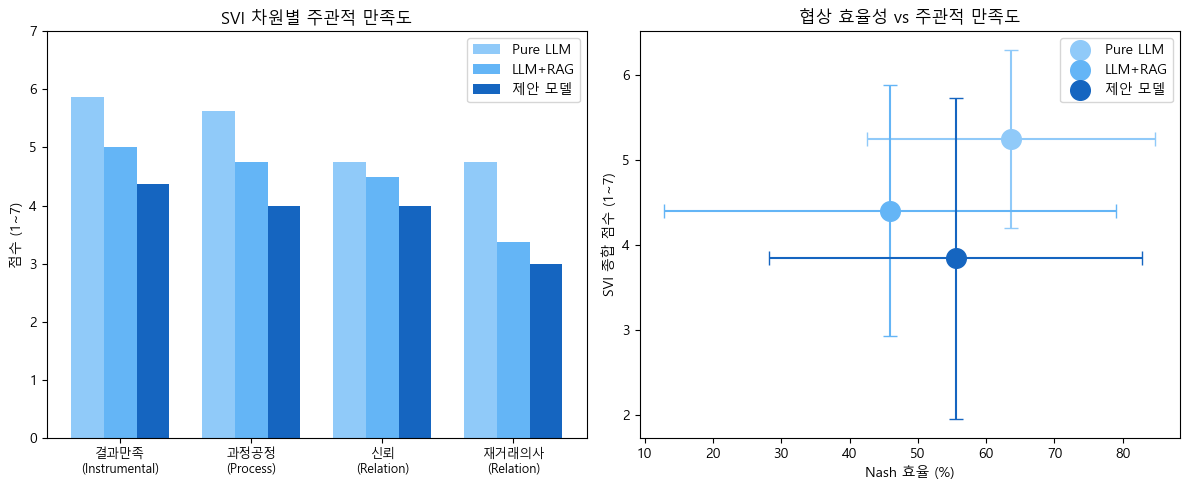

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

modes  = ['pure_llm', 'llm_rag', 'llm_rag_nego_strategy']
labels = ['Pure LLM', 'LLM+RAG', '제안 모델']
colors = ['#90CAF9', '#64B5F6', '#1565C0']

# ── 왼쪽: SVI 차원별 레이더 or 막대 ──
ax = axes[0]
dims = ['satisfaction', 'fairness', 'trust', 'willingness']
dim_labels = ['결과만족\n(Instrumental)', '과정공정\n(Process)', '신뢰\n(Relation)', '재거래의사\n(Relation)']
x = np.arange(len(dims))
width = 0.25

for i, (mode, label, color) in enumerate(zip(modes, labels, colors)):
    vals = [svi_df[svi_df['mode']==mode][d].mean() for d in dims]
    axes[0].bar(x + i*width, vals, width, label=label, color=color)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(dim_labels, fontsize=9)
axes[0].set_ylim(0, 7)
axes[0].set_ylabel('점수 (1~7)')
axes[0].set_title('SVI 차원별 주관적 만족도')
axes[0].legend()

# ── 오른쪽: 파레토 효율 vs SVI 종합 산점도 ──
ax = axes[1]
for mode, label, color in zip(modes, labels, colors):
    sub = svi_df[svi_df['mode'] == mode]
    # 파레토 효율은 앞서 계산한 nash_efficiency 활용
    pareto_vals = df[df['mode'] == mode]['nash_efficiency'] * 100
    svi_vals    = sub['svi_total']
    ax.scatter([pareto_vals.mean()], [svi_vals.mean()],
               s=200, color=color, label=label, zorder=5)
    ax.errorbar(pareto_vals.mean(), svi_vals.mean(),
                xerr=pareto_vals.std(), yerr=svi_vals.std(),
                fmt='none', color=color, capsize=5)

ax.set_xlabel('Nash 효율 (%)')
ax.set_ylabel('SVI 종합 점수 (1~7)')
ax.set_title('협상 효율성 vs 주관적 만족도')
ax.legend()

plt.tight_layout()
plt.savefig('images/svi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [27]:
# ── SVI 통계 검정 ────────────────────────────────────────────
labels = {'pure_llm': 'A', 'llm_rag': 'B', 'llm_rag_nego_strategy': 'C'}

print("=" * 58)
print("SVI 주관적 만족도  |  Permutation test + Cliff's δ")
print("=" * 58)

dims_all = ['satisfaction', 'fairness', 'trust', 'willingness', 'svi_total']
dim_names = {
    'satisfaction': '결과만족 (Instrumental)',
    'fairness':     '과정공정 (Process)',
    'trust':        '신뢰 (Relation-1)',
    'willingness':  '재거래의사 (Relation-2)',
    'svi_total':    'SVI 종합',
}

for dim in dims_all:
    svi_groups = {m: svi_df[svi_df['mode']==m][dim].dropna().values for m in modes}
    vals = [svi_groups[m] for m in modes]
    
    if any(len(v) < 2 for v in vals):
        continue
    
    h, p = kruskal(*vals)
    stars = sig_stars(p)
    print(f"\n[{dim_names[dim]}]  KW: H={h:.3f}, p={p:.4f} {stars}")
    print(f"  평균: " + "  ".join(f"{labels[m]}={svi_groups[m].mean():.2f}" for m in modes))
    
    for a, b in pairs:
        p_raw = perm_p(svi_groups[a], svi_groups[b])
        d, mag = cliffs_delta(svi_groups[a], svi_groups[b])
        print_pair(a, b, p_raw, f"Cliff's δ={d:.2f} [{mag}]")

# ── Nash효율 vs SVI 상관 ─────────────────────────────────────
from scipy.stats import spearmanr

merged = svi_df.merge(df[['session_id','nash_efficiency']], on='session_id')
r, p_r = spearmanr(merged['nash_efficiency'], merged['svi_total'])
print(f"\nNash 효율 × SVI 종합 Spearman r={r:.3f}, p={p_r:.4f} {sig_stars(p_r)}")


SVI 주관적 만족도  |  Permutation test + Cliff's δ

[결과만족 (Instrumental)]  KW: H=2.175, p=0.3371 ns
  평균: A=5.88  B=5.00  C=4.38
  A vs B: p=0.3418  (Bonferroni p=1.0000 ns)  Cliff's δ=0.25 [small]
  A vs C: p=0.1120  (Bonferroni p=0.3360 ns)  Cliff's δ=0.42 [medium]
  B vs C: p=0.6012  (Bonferroni p=1.0000 ns)  Cliff's δ=0.17 [small]

[과정공정 (Process)]  KW: H=2.566, p=0.2772 ns
  평균: A=5.62  B=4.75  C=4.00
  A vs B: p=0.3458  (Bonferroni p=1.0000 ns)  Cliff's δ=0.30 [small]
  A vs C: p=0.1282  (Bonferroni p=0.3846 ns)  Cliff's δ=0.42 [medium]
  B vs C: p=0.5282  (Bonferroni p=1.0000 ns)  Cliff's δ=0.25 [small]

[신뢰 (Relation-1)]  KW: H=0.687, p=0.7092 ns
  평균: A=4.75  B=4.50  C=4.00
  A vs B: p=0.8802  (Bonferroni p=1.0000 ns)  Cliff's δ=0.03 [negligible]
  A vs C: p=0.4892  (Bonferroni p=1.0000 ns)  Cliff's δ=0.25 [small]
  B vs C: p=0.7212  (Bonferroni p=1.0000 ns)  Cliff's δ=0.16 [small]

[재거래의사 (Relation-2)]  KW: H=4.199, p=0.1225 ns
  평균: A=4.75  B=3.38  C=3.00
  A vs B: p=0.1540  (Bonf

# 3가지 지표 통계 검정

In [ ]:
from scipy.stats import permutation_test, fisher_exact, chi2_contingency, kruskal
from itertools import combinations
import numpy as np

modes  = ['pure_llm', 'llm_rag', 'llm_rag_nego_strategy']
labels = {'pure_llm': 'A', 'llm_rag': 'B', 'llm_rag_nego_strategy': 'C'}
pairs  = list(combinations(modes, 2))
N_PAIRS = len(pairs)   # 3 → Bonferroni ×3

# ── 공통 함수 ───────────────────────────────────────────────────
def cliffs_delta(x, y):
    x, y = np.array(x), np.array(y)
    n = len(x) * len(y)
    d = (sum(xi > yi for xi in x for yi in y) -
         sum(xi < yi for xi in x for yi in y)) / n
    mag = ('large' if abs(d) >= 0.474 else
           'medium' if abs(d) >= 0.330 else
           'small'  if abs(d) >= 0.147 else 'negligible')
    return d, mag

def perm_p(x, y, n_resamples=9999):
    def stat(a, b, axis):
        return np.mean(a, axis=axis) - np.mean(b, axis=axis)
    return permutation_test((x, y), stat, n_resamples=n_resamples,
                            alternative='two-sided').pvalue

def sig_stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

def print_pair(a, b, p_raw, effect_str):
    p_corr = min(p_raw * N_PAIRS, 1.0)
    la, lb  = labels[a], labels[b]
    print(f"  {la} vs {b}: p={p_raw:.4f}  "
          f"(Bonferroni p={p_corr:.4f} {sig_stars(p_corr)})  {effect_str}")

# ── ① 규정 준수율 ───────────────────────────────────────────────
print("=" * 58)
print("① 규정 준수율  |  Permutation test + Cliff's δ")
print("=" * 58)

comp = {m: df[df['mode']==m]['compliance_rate'].dropna().values for m in modes}

h, p = kruskal(*[comp[m] for m in modes])
print(f"Kruskal-Wallis (전체): H={h:.3f}, p={p:.4f} {sig_stars(p)}")
print(f"Group means: " + "  ".join(f"{labels[m]}={comp[m].mean()*100:.1f}%" for m in modes))

print("Pairwise:")
for a, b in pairs:
    p_raw = perm_p(comp[a], comp[b])
    d, mag = cliffs_delta(comp[a], comp[b])
    print_pair(a, b, p_raw, f"Cliff's δ={d:.2f} [{mag}]")

# ── ② 타결 성공률 ───────────────────────────────────────────────
print("\n" + "=" * 58)
print("② 타결 성공률  |  Fisher's Exact + Odds Ratio")
print("=" * 58)

succ = {m: df[df['mode']==m]['is_success'].values.astype(bool) for m in modes}

table_3x2 = np.array([[s.sum(), (~s).sum()] for s in succ.values()])
chi2, p_chi2, _, _ = chi2_contingency(table_3x2, correction=False)
print(f"Chi-square (전체): χ²={chi2:.3f}, p={p_chi2:.4f} {sig_stars(p_chi2)}")
print(f"Group rates: " + "  ".join(f"{labels[m]}={succ[m].mean()*100:.1f}%" for m in modes))

print("Pairwise:")
for a, b in pairs:
    t = np.array([[succ[a].sum(), (~succ[a]).sum()],
                  [succ[b].sum(), (~succ[b]).sum()]])
    odds_ratio, p_raw = fisher_exact(t)
    print_pair(a, b, p_raw, f"OR={odds_ratio:.2f}")

# ── ③ 전략 일관성 ───────────────────────────────────────────────
print("\n" + "=" * 58)
print("③ 전략 일관성  |  Permutation test + Cliff's δ")
print("=" * 58)

sess_cons = consist_df.groupby(['session_id','mode'])['score'].mean().reset_index()
cons = {m: sess_cons[sess_cons['mode']==m]['score'].values for m in modes}

h, p = kruskal(*[cons[m] for m in modes])
print(f"Kruskal-Wallis (전체): H={h:.3f}, p={p:.4f} {sig_stars(p)}")
print(f"Group means: " + "  ".join(f"{labels[m]}={cons[m].mean():.2f}" for m in modes))

print("Pairwise:")
for a, b in pairs:
    p_raw = perm_p(cons[a], cons[b])
    d, mag = cliffs_delta(cons[a], cons[b])
    print_pair(a, b, p_raw, f"Cliff's δ={d:.2f} [{mag}]")


① 규정 준수율  |  Permutation test + Cliff's δ


KeyError: 'compliance_rate'

## 7. 논문 표 1 요약

In [ ]:
# 각 지표를 모드 순서(A→B→C)로 정렬하여 표 생성
MODE_ORDER = ['pure_llm', 'llm_rag', 'llm_rag_nego_strategy']
DISPLAY_NAMES = {
    'pure_llm':              'Baseline LLM (조건 A)',
    'llm_rag':               'LLM + RAG (조건 B)',
    'llm_rag_nego_strategy': 'LLM + RAG + Negotiation Strategy (조건 C)',
}

# 지표 1: 규정 준수율
comp = df.groupby('mode')['compliance_rate'].mean().mul(100).round(1).rename('규정 준수율 (%)')

# 지표 2: 타결 성공률
succ = df.groupby('mode')['is_success'].mean().mul(100).round(1).rename('타결 성공률 (%)')

# 지표 3: 전략 일관성 (LLM-as-Judge)
cons = consist_df.groupby('mode')['score'].mean().round(2).rename('전략 일관성 점수')

result_table = pd.DataFrame([comp, succ, cons]).T
result_table.index = result_table.index.map(DISPLAY_NAMES)
result_table = result_table.reindex([DISPLAY_NAMES[m] for m in MODE_ORDER if m in result_table.index])

print('\n========== 논문 표 1 결과 요약 ==========')
print(result_table.to_string())
print('=========================================')

## 8. 시각화

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels = [DISPLAY_NAMES.get(m, m).replace(' (', '\n(') for m in MODE_ORDER if m in df['mode'].unique()]
modes  = [m for m in MODE_ORDER if m in df['mode'].unique()]

# ── 규정 준수율 ──
ax = axes[0]
vals = [df[df['mode']==m]['compliance_rate'].mean()*100 for m in modes]
errs = [df[df['mode']==m]['compliance_rate'].std()*100 for m in modes]
bars = ax.bar(labels, vals, yerr=errs, capsize=5, color=['#90CAF9','#64B5F6','#1565C0'])
ax.set_ylim(0, 110)
ax.set_ylabel('준수율 (%)')
ax.set_title('규정 준수율')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+2, f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# ── 타결 성공률 ──
ax = axes[1]
vals = [df[df['mode']==m]['is_success'].mean()*100 for m in modes]
bars = ax.bar(labels, vals, color=['#A5D6A7','#66BB6A','#1B5E20'])
ax.set_ylim(0, 110)
ax.set_ylabel('성공률 (%)')
ax.set_title('타결 성공률')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+2, f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# ── 전략 일관성 점수 ──
ax = axes[2]
vals = [consist_df[consist_df['mode']==m]['score'].mean() for m in modes]
errs = [consist_df[consist_df['mode']==m]['score'].std() for m in modes]
bars = ax.bar(labels, vals, yerr=errs, capsize=5, color=['#FFCC80','#FFA726','#E65100'])
ax.set_ylim(0, 5.5)
ax.set_ylabel('점수 (1~5)')
ax.set_title('전략 일관성 점수\n(LLM-as-Judge)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.1, f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/result_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: images/result_summary.png')

In [ ]:
# 대화 턴 수 분포 (참고용)
def count_turns(row):
    human_role = row.get('human_role', '')
    return sum(1 for m in row['message_history']
               if m.get('speaker') == human_role)

df['turn_count'] = df.apply(count_turns, axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
for mode in modes:
    subset = df[df['mode'] == mode]['turn_count']
    ax.hist(subset, bins=range(1, 22), alpha=0.6, label=DISPLAY_NAMES.get(mode, mode))
ax.set_xlabel('사용자 턴 수')
ax.set_ylabel('세션 수')
ax.set_title('모드별 대화 턴 수 분포')
ax.legend()
plt.tight_layout()
plt.savefig('images/turn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 원본 데이터 내보내기

In [ ]:
# 메시지 히스토리는 CSV 저장에 적합하지 않으므로 제외
export_cols = ['session_id','raw_mode','mode','human_role','ai_role',
               'buyer_points','seller_points','is_success','compliance_rate',
               'turn_count','timestamp','evaluation_details']

df[export_cols].to_csv('results_export.csv', index=False, encoding='utf-8-sig')
consist_df.to_csv('consistency_scores.csv', index=False, encoding='utf-8-sig')

print('저장 완료:')
print('  experiments/results_export.csv')
print('  experiments/consistency_scores.csv')